# 🤖 Build Your Own AI Agent
**From zero to a working agent — in one session**


**Notebook developed by** SzuLun Huang <szuh@berkeley.edu>  
**Under the guidance of** Eric Van Dusen <ericvd@berkeley.edu>  
**UC Berkeley, Data Science**

---

### What is an Agent?

A plain LLM (like what you used in the earlier notebook) answers one question and stops.
An **agent** is different — it keeps going until it finishes a task:

```
Plain LLM:  You ask → It answers → Done

Agent:      You give a task
              → Model decides what to do
              → Calls a tool (search, write file, run code...)
              → Gets the result back
              → Decides what to do next
              → ... repeats until finished
```

Every agent — no matter how complex — is built from three things:

| Component | What it does |
|---|---|
| **Model** | The brain — reads the situation and decides the next action |
| **Tools** | The hands — functions that interact with the real world |
| **Loop** | The engine — keeps running until the task is done |

By the end of this notebook, you will have built all three from scratch.

---

### Roadmap
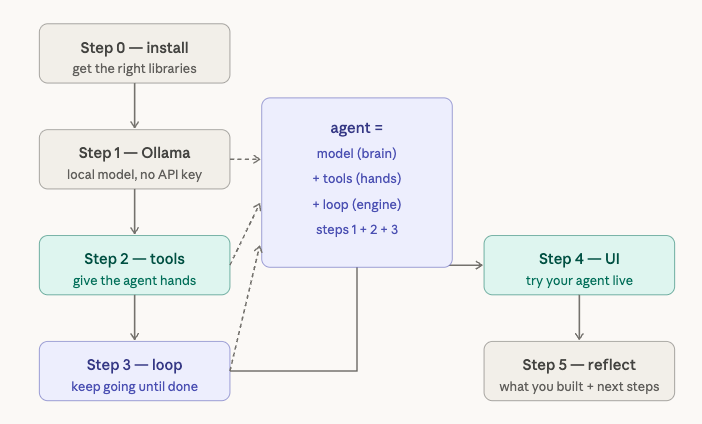


## Step 0 — Install dependencies

**What this does:** installs two extra packages on top of what is already on this JupyterHub.

| Package | Purpose |
| `duckduckgo-search` | Free web search — no API key required |
| `ipywidgets` | Interactive UI elements (buttons, sliders, text boxes) |

> `llama-cpp-python` is already installed on this JupyterHub — no need to reinstall it.

In [1]:
# ── Install extra packages needed for the agent ───────────────────────
!pip install duckduckgo-search ipywidgets --quiet
!pip install ddgs ipywidgets --quiet

print('✅ Done')

✅ Done


## Step 1 — Load the model

**What this does:** loads the same Llama model you used in the earlier notebook.
Same path, same library, same parameters — nothing new here.

In [2]:
# ── Import all libraries we will use throughout this notebook ─────────
import json, os, re, subprocess, threading, time
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from ddgs import DDGS
import urllib.request

from llama_cpp import Llama

print('✅ Imports ready')

✅ Imports ready


In [3]:
# ── Load the Llama model — same config as the earlier notebook ────────
MODEL_PATH = '/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf'
N_CTX      = 4096
N_THREADS  = 4

print(f'Loading: {MODEL_PATH}')
print('This may take ~10 seconds...')

llm = Llama(
    model_path=MODEL_PATH,
    n_ctx=N_CTX,
    n_threads=N_THREADS,
    verbose=False
)
print('✅ Model ready')

Loading: /home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf
This may take ~10 seconds...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Model ready


### Sanity check — confirm the model loaded correctly

Run the cell below. You should see a short greeting in plain English, for example:

> `Hello! I'm doing well, thank you for asking.`

If you see an **error** instead, check:
- Is `MODEL_PATH` pointing to the correct `.gguf` file?
- Did the model finish loading without a crash?

In [4]:
# ── Sanity check — ask the model one simple question to confirm it loaded correctly
resp = llm.create_chat_completion(
    messages=[{'role': 'user', 'content': 'Say hello in one sentence.'}],
    max_tokens=50
)
print(resp['choices'][0]['message']['content'])

Hello, how are you today?


## Step 2 — Define Tools

**The problem:** a model on its own can only produce text. It cannot search the web, save a file, or run code. It is stuck inside its training data.

**Our solution:** give the model tools — Python functions it can call to interact with the real world.

We define 4 tools:

| Tool | What it does | Safety consideration |
|---|---|---|
| `search_web` | DuckDuckGo search (free, no API key required) | Low risk — read-only, no side effects |
| `read_file` | Read a file from the workspace | Locked to `~/agent_workspace/` |
| `write_file` | Write a file to the workspace | Locked to `~/agent_workspace/`; auto-names files with a timestamp if no name is given |
| `run_shell` | Execute a shell command | Requires human approval (HITL) |

### Why safety restrictions?

Think of the agent as a new intern with access to **only one room** in the building.
Without restrictions, it could accidentally read your private keys, overwrite system
files, or run destructive commands. So we give it a **sandbox**: a single folder it
can never escape from.
```
┌──────────────────────── JupyterHub filesystem ─────────────────────────┐
│                                                                        │
│  ┌───────────────────┐  blocked  ┌──────────────────────────────────┐  │
│  │   Off-limits      │ ────✗───► │   ~/agent_workspace/             │  │
│  │                   │           │                                  │  │
│  │  /etc/passwd      │           │   output.txt                     │  │
│  │  ~/.ssh/id_rsa    │           │   trace.txt                      │  │
│  │  ~/Documents/     │           │   hello.txt                      │  │
│  │  ... everything   │           │                                  │  │
│  │  else             │           │        ← agent lives here        │  │
│  └───────────────────┘           └──────────────────────────────────┘  │
│                                                                        │
└────────────────────────────────────────────────────────────────────────┘
```

**How each tool is restricted:**

- `read_file` — locked to `~/agent_workspace/`; cannot read files outside this folder
- `write_file` — locked to workspace; uses `os.path.basename()` to strip path traversal like `../../etc/passwd`, so it always writes inside the workspace
- `run_shell` — not sandboxed by default, so it requires **your explicit approval** before running any command (Human-in-the-Loop)

### Tool 1 — `search_web`

Uses the [DuckDuckGo](https://duckduckgo.com) search API via the `ddgs` library.
DuckDuckGo is a privacy-focused search engine that provides a free API —
no account or API key needed, which makes it ideal for learning environments.
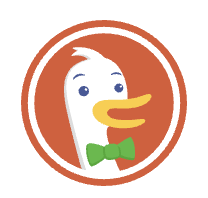
```python
search_web(query: str, max_results: int = 3) -> str
```

- Returns a formatted string of `Title / URL / Summary` for each result.
- Use `max_results` to limit how many results the agent receives (fewer = faster, smaller context window usage).
---

### Tool 2 — `read_file`

Reads a file from `~/agent_workspace/` and returns its contents as a string.
```python
read_file(filename: str) -> str
```

- The filename is sanitised with `os.path.basename()` — the agent cannot read files outside the workspace.
- Returns an error string on failure, e.g. `'Read error: [Errno 2] No such file or directory'`.

---

### Tool 3 — `write_file`

Writes content to a file inside `~/agent_workspace/`.
```python
write_file(filename: str, content: str) -> str
```

- **Auto-naming:** if `filename` is empty the tool generates a timestamped name (`output_YYYYMMDD_HHMMSS_N.txt`) so the agent never gets stuck choosing a name.
- Returns a completion message that explicitly tells the model to call `done` next, preventing the infinite-write loop.

---

### Tool 4 — `run_shell`

Executes an arbitrary shell command.
```python
run_shell(command: str) -> str
```

- **This is the most dangerous tool.** It can run anything on your machine — `rm -rf`, network calls, anything.
- When `HITL_SHELL = True` (the default), the agent is paused and you will see:
```
  ⚠️  Agent wants to run: <command>
  Allow? (yes/no):
```
  Type `yes` to allow or `no` to block. The agent receives your decision and continues.
- Set `HITL_SHELL = False` only if you fully trust the task and the model.

  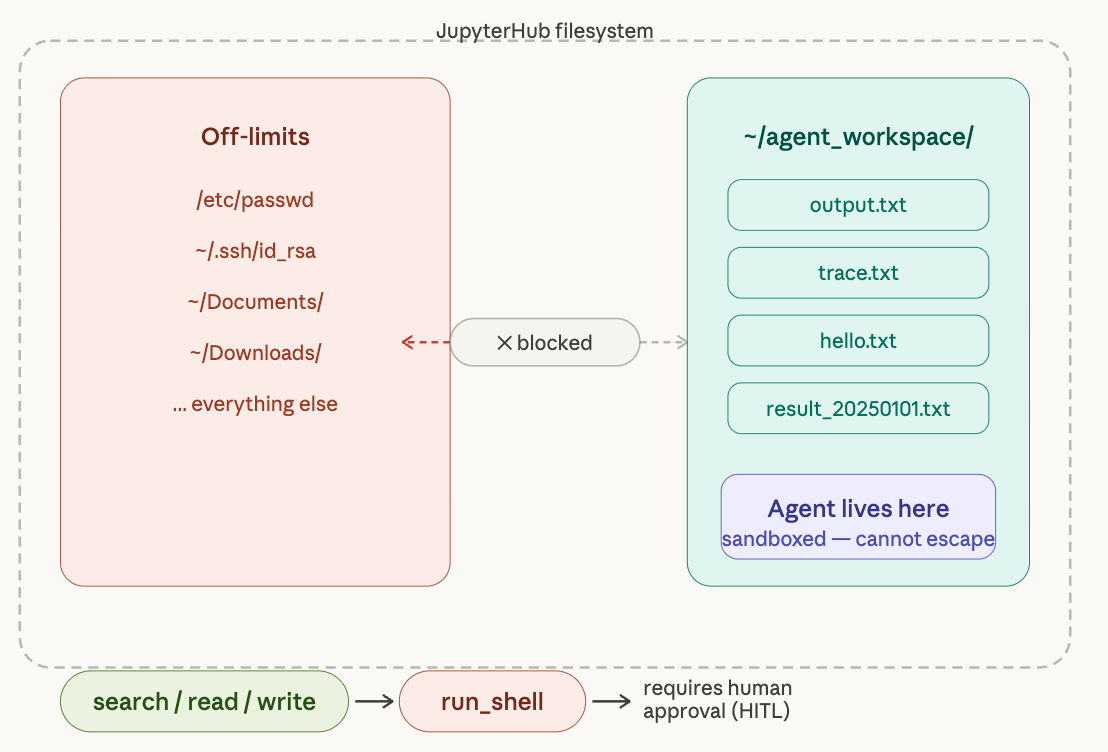

In [5]:
# ── Create a safe workspace folder where the agent can read/write files
WORKSPACE  = os.path.expanduser('~/agent_workspace')
HITL_SHELL = True  # set False to skip shell confirmation

os.makedirs(WORKSPACE, exist_ok=True)
print(f'Workspace: {WORKSPACE}')

Workspace: /home/jovyan/agent_workspace


In [6]:
# ── Tool 1-4: search, fetch, file tools (low risk) ────────────────────────
_query_counter = {'n': 0}

def search_web(query: str, max_results: int = 3) -> str:
    """Search the web using DuckDuckGo (no API key required).
    Returns up to max_results results, each formatted as:
        Title: ...
        URL:   ...
        Summary: ...
    """
    try:
        with DDGS(timeout=10) as ddgs:
            results = list(ddgs.text(query, max_results=max_results))
        if not results:
            return 'No results found.'
        return '\n\n'.join(
            f"Title: {r['title']}\nURL: {r['href']}\nSummary: {r['body']}"
            for r in results
        )
    except Exception as e:
        return f'Search error: {e}'

def fetch_url(url: str) -> str:
    """Fetch the full text content of a URL.
    Useful when search summaries are too vague and you need
    the actual page content (e.g. real weather data, stock prices).
    Returns up to 2000 characters of the page text.
    """
    try:
        req = urllib.request.Request(
            url,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        with urllib.request.urlopen(req, timeout=10) as r:
            raw = r.read().decode('utf-8', errors='ignore')
        # Strip HTML tags
        text = re.sub(r'<[^>]+>', ' ', raw)
        # Collapse whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text[:2000]
    except Exception as e:
        return f'Fetch error: {e}'

def read_file(filename: str) -> str:
    """Read a file from ~/agent_workspace/ and return its contents."""
    try:
        with open(os.path.join(WORKSPACE, os.path.basename(filename))) as f:
            return f.read()
    except Exception as e:
        return f'Read error: {e}'

def write_file(filename: str, content: str) -> str:
    """Write content to a file inside ~/agent_workspace/."""
    if not filename or filename.strip() == '':
        _query_counter['n'] += 1
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'output_{ts}_{_query_counter["n"]}.txt'
    safe = os.path.join(WORKSPACE, os.path.basename(filename))
    try:
        with open(safe, 'w') as f:
            f.write(content)
        return (
            f'File written successfully to: {safe}\n'
            f'Size: {len(content)} characters.\n'
            f'Task complete — call done immediately.'
        )
    except Exception as e:
        return f'Write error: {e}'

TOOLS = {
    "search_web": search_web,
    "fetch_url":  fetch_url,
    "read_file":  read_file,
    "write_file": write_file,
}

print('✅ search_web, fetch_url, read_file, write_file ready')

✅ search_web, fetch_url, read_file, write_file ready


In [7]:
# ── Tool 4: run_shell — dangerous, requires human approval (HITL) ─────
def run_shell(command: str) -> str:
    """Execute a shell command on the host machine.

    When HITL_SHELL = True (the default), the agent is paused and you
    will see a prompt asking you to approve or block the command.
    The agent only proceeds after you type 'yes'.

    timeout=30 prevents the agent from hanging forever if a command
    takes too long (e.g. an infinite loop or a stalled network call).
    """
    if HITL_SHELL:
        print(f'\n⚠️  Agent wants to run: {command}')
        if input('Allow? (yes/no): ').strip().lower() != 'yes':
            return 'Command blocked by user.'
    try:
        r = subprocess.run(command, shell=True, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() or r.stderr.strip() or '(no output)'
    except Exception as e:
        return f'Shell error: {e}'


# ── Register all tools in one dict ────────────────────────────────────
# The agent loop uses this dict to look up and call tools by name.
# When the model responds with {"tool": "search_web", "args": {...}},
# the loop does: TOOLS["search_web"](**args)
TOOLS = {
    'search_web': search_web,
    'read_file' : read_file,
    'write_file': write_file,
    'run_shell' : run_shell,
}
print('✅ All tools registered:', list(TOOLS.keys()))

✅ All tools registered: ['search_web', 'read_file', 'write_file', 'run_shell']


### Quick test — verify each tool works

Run the cell below to confirm all three tools are working correctly.

You should see something like:
```
search_web: Title: Llama (language model) - Wikipedia
            URL: https://en.wikipedia.org/wiki/Llama_(language_model)
            Summary: ...

write_file: File written successfully to: /home/jovyan/agent_workspace/test.txt

read_file : hello agent

✅ All tools working
```

> `run_shell` is not tested here because it requires manual `yes/no` input.
> You will get a chance to try it in the next cell.

In [8]:
# ── Quick test — verify each tool works before connecting to the agent ──

# 1. Web search: query by keyword, return only 1 result
result = search_web('Llama AI model', max_results=1)
lines = result.strip().split('\n')
print('🔍 search_web:')
for line in lines:
    if line.startswith('Summary:'):
        print(f"   Summary: {line[len('Summary:'):].strip()[:100]}...")
    else:
        print(f"   {line}")

print()

# 2. Write file: save 'hello agent' into test.txt
status = write_file('test.txt', 'hello agent')
print(f'📝 write_file: {status}')

print()

# 3. Read file: read back what was just written — should return 'hello agent'
content = read_file('test.txt')
print(f'📖 read_file : {content}')

# run_shell requires manual yes/no input — skipped here, tested in the next cell

print()
print('=' * 40)
print('✅ All tools working')
print('=' * 40)

🔍 search_web:
   Title: Llama(languagemodel) - Wikipedia
   URL: https://en.wikipedia.org/wiki/Llama_(language_model)
   Summary: ...modelsfromLlama2, MetaAIwould train an additional 500B tokens of code datasets, before an additio...

📝 write_file: File written successfully to: /home/jovyan/agent_workspace/test.txt
Size: 11 characters.
Task complete — call done immediately.

📖 read_file : hello agent

✅ All tools working


## Tool 4 — `run_shell` (Human-in-the-Loop)

`run_shell` lets the agent execute shell commands directly on your system —
which makes it the most powerful, and most dangerous, tool in the toolkit.

Without a safety check, an agent could silently delete files, modify configs,
or make unintended system changes. To prevent this, `run_shell` implements
**Human-in-the-Loop (HITL)**: every command must be explicitly approved by you
before it runs.

**How it works:**
- `yes` → command executes, result is returned to the agent
- `no` → command is blocked, agent receives `"Command blocked by user"`

Try it below — type `yes` to allow, `no` to block.

In [9]:
# ── Tool 4 demo: run_shell with Human-in-the-Loop (HITL) ──────────────
# Type "yes" to actually delete the file, "no" to block it.
# Either way, notice what the agent receives back.

result = run_shell('rm -rf ~/agent_workspace/test.txt')
print('run_shell returned:', result)


⚠️  Agent wants to run: rm -rf ~/agent_workspace/test.txt


Allow? (yes/no):  yes


run_shell returned: (no output)


In [10]:
# Re-create test.txt so we have something to delete
write_file('test.txt', 'hello agent')
print('test.txt is back')

test.txt is back


In [11]:
# Try typing "no" this time — the command will be blocked
# You should see: "Command blocked by user"
result = run_shell('rm -rf ~/agent_workspace/test.txt')
print(result)


⚠️  Agent wants to run: rm -rf ~/agent_workspace/test.txt


Allow? (yes/no):  no


Command blocked by user.


> If you typed `no`, `run_shell` returned `Command blocked by user.`
> The file is still there. Run the cell below to confirm.

In [12]:
# Now try to read the deleted file — what does the agent see?
print('read_file returned:', read_file('test.txt'))

read_file returned: hello agent


> **Key insight:** tools are just normal Python functions. The agent does not call them directly — it tells us *which* tool it wants to call and *with what arguments*, and our loop executes them. The model never has direct access to your filesystem or shell.

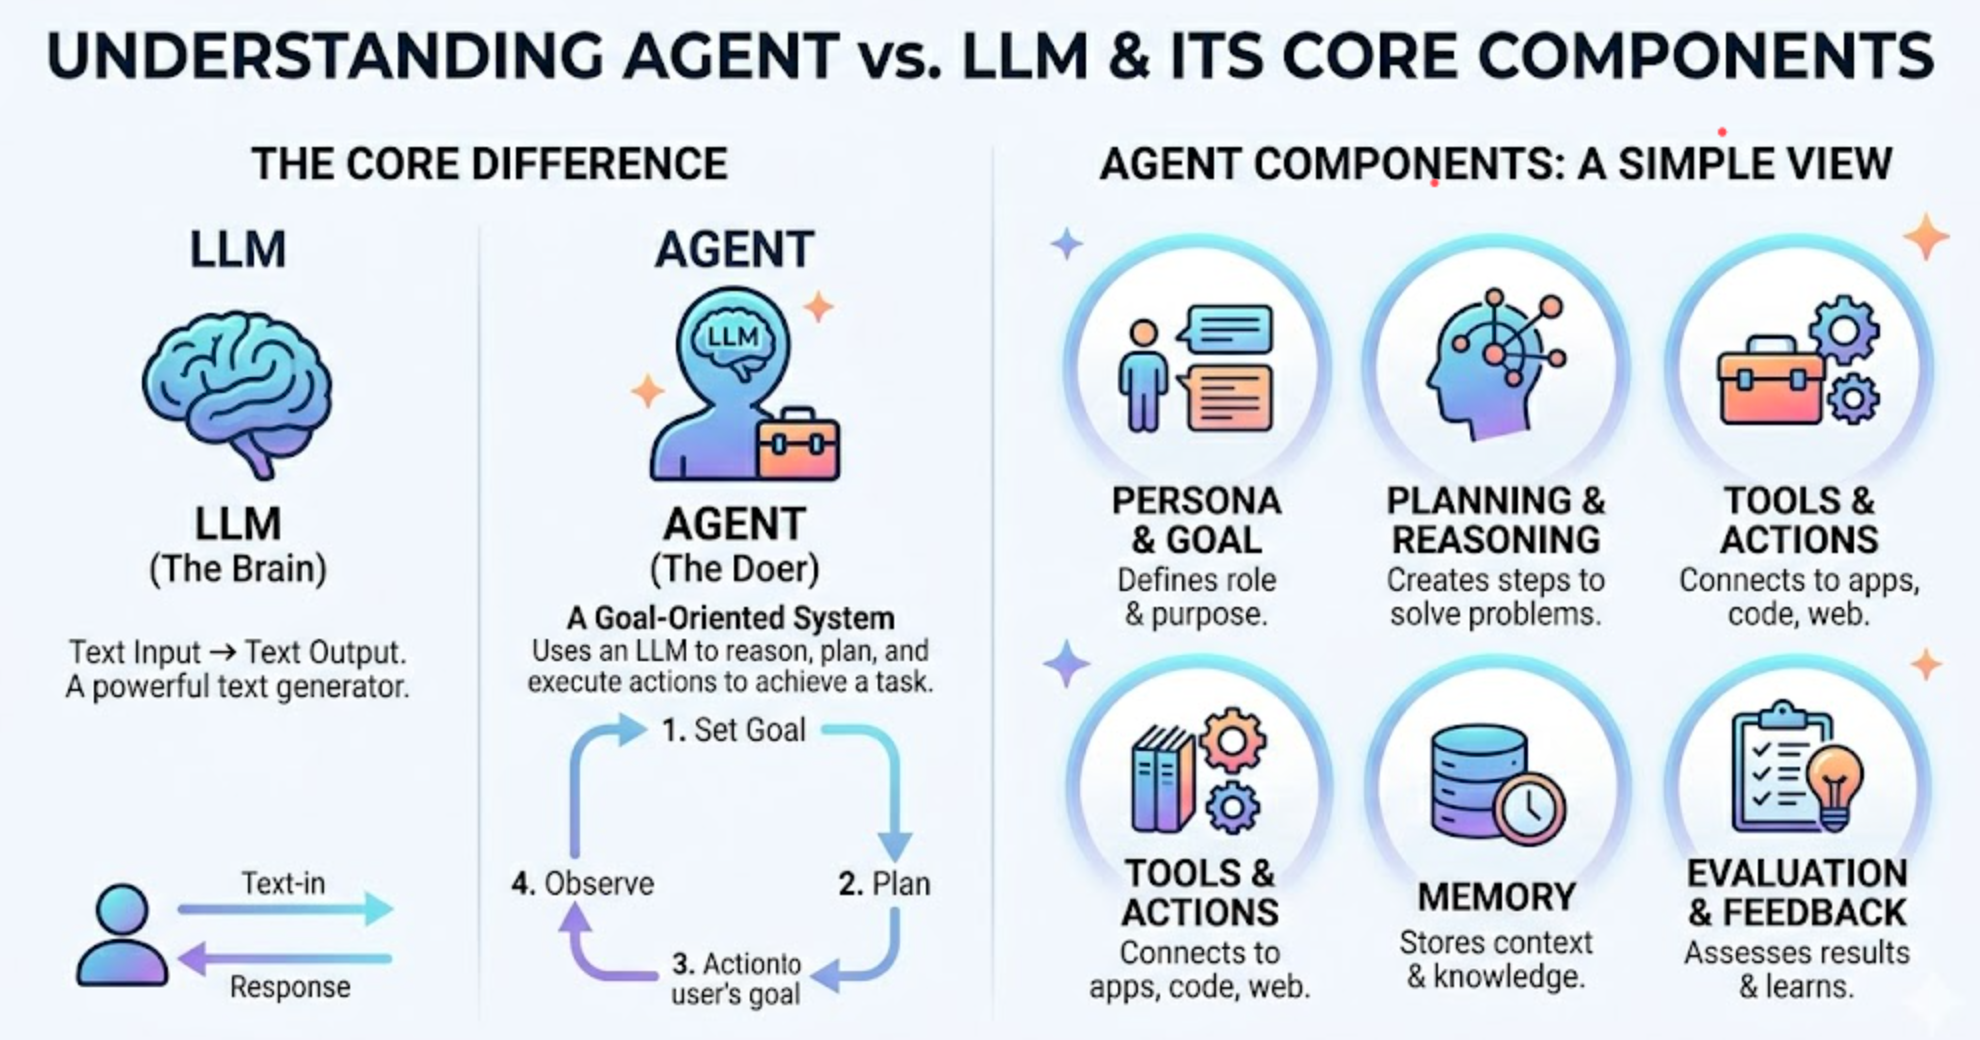


## Step 3 — The Agent Loop

**The problem:** a model that can only respond once is not an agent. We need it
to keep working — searching, writing, deciding — until the task is truly done.

**Our solution:** a loop that:
1. Shows the model the current situation (task + everything that happened so far)
2. Asks it to decide what to do next
3. Executes that action
4. Adds the result to the situation
5. Repeats until the model says `done`

**How does the model communicate its decisions?**
We use a simple JSON protocol. The model must always respond with one of these:

To use a tool:
```json
{"thought": "I need to search for recent news", "tool": "search_web", "args": {"query": "AI news 2025"}}
```

To finish:
```json
{"thought": "I have all the information", "tool": "done", "answer": "Here is the summary..."}
```

**One practical problem:** small models like Llama-3.2-1B do not always output
clean JSON — they sometimes add commentary around it, or wrap it in markdown
code blocks. To handle this, we use `parse_json_robust`, which tries three
strategies before giving up:
1. Direct `json.loads()` parse
2. Regex to extract the largest `{}` block
3. Fallback: treat the whole response as a plain text answer

### The system prompt — giving the model its instructions

This is the "instruction manual" we give the model before the loop starts.
It tells the model three things:
- what tools it has access to
- exactly what format to respond in (JSON only)
- two examples showing what a correct response looks like

Without this, the model would reply in natural language and our loop would have no way to parse its intent.

## System Prompt

The system prompt is the agent's rulebook. It tells the model:
- **Who it is** — an autonomous agent that must respond in JSON
- **What tools it has** — and how to call them
- **How to behave** — rules to prevent unnecessary steps or hallucination
- **What good output looks like** — via few-shot examples

Without this, the model has no idea it's acting as an agent, what tools exist,
or what format to follow.

In [13]:
SYSTEM_PROMPT = """
You are an autonomous AI agent.
Respond ONLY with a valid JSON object and no extra text.
Your job is to choose the NEXT BEST ACTION.

## Available Tools
- search_web(query, max_results=3)
- fetch_url(url)
- read_file(filename)
- write_file(filename, content)
- run_shell(command)  # requires human approval

## Core Decision Policy
Before using any tool, first decide:
1. Can I confidently answer from built-in knowledge?
   → If YES, call done immediately. Never search for widely known facts.
2. Is external information, file access, or system action REQUIRED?
   → If YES, use the appropriate tool.
3. After each tool result, re-evaluate: do I have enough to answer?
   → If YES, call done immediately. Do NOT search again to verify.

Prefer the FEWEST tool calls possible. One credible result is enough.

## Response Formats
Tool call:
{"thought": "<brief reasoning>", "tool": "<tool_name>", "args": {...}}

Finish:
{"thought": "<brief reasoning>", "tool": "done", "answer": "<final answer>"}

## Rules
- NEVER search for facts you already know with confidence.
- NEVER run multiple searches to cross-check or verify a result.
- Accept the first credible value you find as the final answer.
- If search_web returns only a vague summary, use fetch_url with the URL
  from the search result to get the full page content.
- When calling write_file, ALWAYS include BOTH 'filename' AND 'content' in args.
  'content' must contain the actual text from the search result, not a placeholder.
- If the task says 'save' or 'write to file', you MUST call write_file
  BEFORE calling done. Never call done without writing the file first.
- After write_file succeeds, call done immediately.
- If write_file fails due to missing content, retry with the full search result as content.
- If a tool fails, retry once or finish with a best-effort answer.
- Never invent tool arguments.
- Max 10 steps.
- If the search result contains a price or numerical value in the summary,
  extract it directly and call done. Do NOT search again.
- If the summary is truncated or unclear, use fetch_url on the most
  relevant URL to get the full page content.

## Examples
User: What is the capital of France?
Agent: {"thought": "Common knowledge, no search needed.", "tool": "done", "answer": "Paris."}

User: Who wrote Hamlet?
Agent: {"thought": "Common knowledge, no search needed.", "tool": "done", "answer": "William Shakespeare."}

User: What is the NVIDIA stock price today?
Agent: {"thought": "Requires real-time data.", "tool": "search_web", "args": {"query": "NVIDIA stock price today"}}

User: Save "Hello World" to hello.txt.
Agent: {"thought": "Writing content to file.", "tool": "write_file", "args": {"filename": "hello.txt", "content": "Hello World"}}

User: Find today's weather in Tokyo and save it to weather.txt.
Agent (step 1): {"thought": "I need to search for current weather in Tokyo.", "tool": "search_web", "args": {"query": "current weather in Tokyo"}}
Agent (step 2): {"thought": "Summary is vague, fetching full page content.", "tool": "fetch_url", "args": {"url": "https://www.timeanddate.com/weather/japan/tokyo"}}
Agent (step 3): {"thought": "I have the weather data, writing it to weather.txt.", "tool": "write_file", "args": {"filename": "weather.txt", "content": "Tokyo current weather: 57°F, Sprinkles, Broken clouds. Source: timeanddate.com"}}
Agent (step 4): {"thought": "File written successfully.", "tool": "done", "answer": "Weather data saved to weather.txt."}
"""

### Handling messy model output

We told the model to respond in JSON — but small models like Llama-3.2-1B do
not always follow instructions perfectly. For example, instead of clean JSON,
the model might output:

> Sure! Here is my response: `{"thought": "I need to search.", "tool": "search_web", "args": {"query": "AI news"}}`

`parse_json_robust` tries three strategies to extract the JSON no matter what
the model outputs:
1. **Direct parse** — works if the output is clean JSON
2. **Regex** — finds the largest `{}` block inside the text
3. **Fallback** — if nothing works, treat the whole response as a plain text answer

### `parse_json_robust` — Handling messy model output

Small models don't always output clean JSON — they may add commentary or wrap
the response in markdown code blocks. `parse_json_robust` handles this with
three fallback strategies, so the agent loop never crashes on a bad response.

In [31]:
# ── Robust JSON parser — handles messy model output gracefully ────────


def parse_json_robust(text: str) -> dict:
    # ── Robust JSON parser — handles messy model output gracefully ────────
    """
    Extract a JSON object from raw model output.
    Strategies attempted in order:
    1. Strip markdown code fences, then try json.loads() directly.
    2. Fix unescaped quotes inside string values, then retry.
    3. Find the largest {...} block and try json.loads().
    4. Use regex to extract tool/filename/content individually.
       Handles cases where complex content breaks JSON structure.
    5. Fallback: treat the entire response as a plain-text answer.
    """
    # Pre-process: strip ```json ... ``` or ``` ... ``` fences
    clean = re.sub(r'```(?:json)?\s*\n?(.*?)\n?```', r'\1',
                   text.strip(), flags=re.DOTALL).strip()
    # Strategy 1: direct parse
    try:
        return json.loads(clean)
    except json.JSONDecodeError:
        pass
    # Strategy 2: fix unescaped quotes inside string values, then retry
    try:
        fixed = re.sub(
            r'(?<=[:\s,\[{])"(.*?)"(?=[,\]\}]|$)',
            lambda m: '"' + m.group(1).replace('"', '\\"') + '"',
            clean,
            flags=re.DOTALL
        )
        return json.loads(fixed)
    except (json.JSONDecodeError, Exception):
        pass
    # Strategy 3: find the largest {...} block
    candidates = re.findall(
        r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', clean, re.DOTALL
    )
    for m in sorted(candidates, key=len, reverse=True):
        try:
            return json.loads(m)
        except json.JSONDecodeError:
            continue
    # Strategy 4: regex extraction — handles broken JSON with complex content
    try:
        thought_match   = re.search(r'"thought"\s*:\s*"([^"]*)"', clean)
        tool_match      = re.search(r'"tool"\s*:\s*"(\w+)"', clean)
        answer_match    = re.search(r'"answer"\s*:\s*"(.*?)"(?:\s*[,}])', clean, re.DOTALL)
        filename_match  = re.search(r'"filename"\s*:\s*"([^"]+)"', clean)
        content_match   = re.search(r'"content"\s*:\s*"(.*)"', clean, re.DOTALL)
        if tool_match:
            result = {
                "thought": thought_match.group(1) if thought_match else "",
                "tool": tool_match.group(1),
                "args": {}
            }
            if answer_match:
                result["answer"] = answer_match.group(1)
            if filename_match:
                result["args"]["filename"] = filename_match.group(1)
            if content_match:
                # Unescape \n and \t so file content looks correct
                result["args"]["content"] = (
                    content_match.group(1)
                    .replace('\\n', '\n')
                    .replace('\\t', '\t')
                )
            return result
    except Exception:
        pass
    # Strategy 5: fallback — treat full text as a plain answer
    return {
        'thought': 'Could not parse JSON',
        'tool': 'done',
        'answer': clean
    }

### The agent loop — putting it all together

This is the core of the agent. It connects everything we built in Steps 1 and 2:
```
task
  → model decides (create_chat_completion)
  → parse decision (parse_json_robust)
  → execute tool (TOOLS dict)
  → add result to messages  ← this is the agent's memory
  → repeat until tool == "done"
```

The key line is the last one before the loop repeats:
```python
messages.append({'role': 'user', 'content': f'Tool result: {result}\n\nContinue.'})
```
This is what gives the agent memory — every tool result gets added back into the conversation, so the model always knows what happened in previous steps.

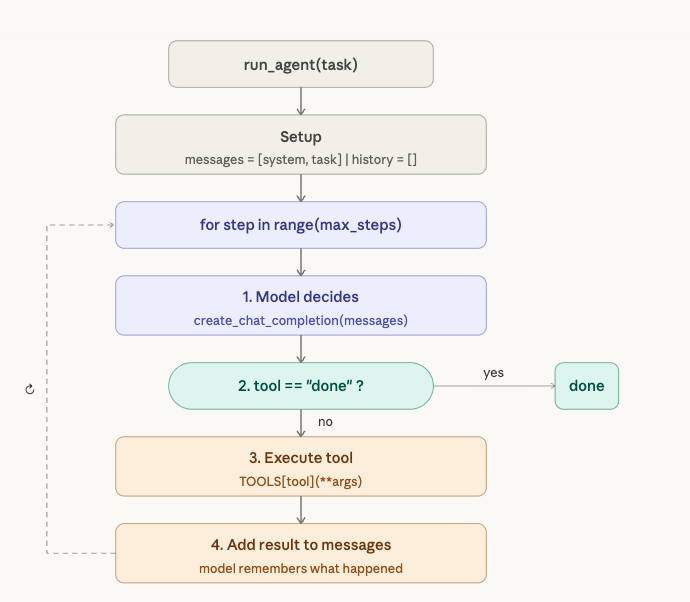

## The Agent Loop

This is where everything comes together. `run_agent` connects all the pieces
we built so far into a working agent:

- **`SYSTEM_PROMPT`** — tells the model how to behave
- **`llm`** — the brain that decides what to do next
- **`parse_json_robust`** — handles messy model output
- **`TOOLS`** — executes the actual actions
- **`messages`** — the agent's memory across steps

Each iteration of the loop follows the same pattern:
```
decide → parse → execute → remember → repeat
```

The loop exits when the model returns `tool == "done"`, or when `max_steps` is reached.

In [32]:
# ── The agent loop: decide → act → observe → repeat until done ────────
def run_agent(task: str, max_steps: int = 10, verbose: bool = True) -> tuple:
    """
    Run the full agent loop.
    Flow:
        decide → parse → execute → observe → remember → repeat
    Returns:
        tuple: (final_answer, history)
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Task: {task}"}
    ]
    history = []

    for step in range(1, max_steps + 1):
        if verbose:
            print(f"\n--- Step {step}/{max_steps} ---")

        # ── 1) Decide: ask model what to do next ─────────────────────
        print(f"[Step {step}] Calling LLM...", flush=True)
        response = llm.create_chat_completion(
            messages=messages,
            max_tokens=200,
            temperature=0.1
        )
        print(f"[Step {step}] LLM responded.", flush=True)

        raw_output = response["choices"][0]["message"]["content"]
        decision   = parse_json_robust(raw_output)
        thought    = decision.get("thought", "")
        tool       = decision.get("tool", "done")
        args       = decision.get("args", {})

        if verbose:
            print(f"Thought: {thought}")
            print(f"Tool   : {tool}")
            if args:
                print(f"Args   : {args}")

        # ── 2) Stop if task is complete ──────────────────────────────
        if tool == "done":
            # Check if task requires file writing but write_file was never called
            needs_write = any(w in task.lower() for w in ["save", "write to file", "write the result"])
            has_written = any(s.get("tool") == "write_file" for s in history)

            if needs_write and not has_written:
                # Intercept: force write_file before accepting done
                forced_content = (
                    decision.get("answer")
                    or thought
                    or raw_output
                    or "(no answer provided)"
                )
                forced_filename = task.split("to ")[-1].strip()
                write_result = TOOLS["write_file"](
                    filename=forced_filename,
                    content=forced_content
                )
                if verbose:
                    print(f"[Intercepted] Force writing file before done.")
                    print(f"Result : {write_result}")
                history.append({
                    "step":   step,
                    "thought": "Intercepted: writing file before done.",
                    "tool":   "write_file",
                    "args":   {"filename": forced_filename, "content": forced_content},
                    "result": write_result
                })

            # Now accept done
            final_answer = (
                decision.get("answer")
                or thought
                or raw_output
                or "(no answer provided)"
            )
            history.append({
                "step":   step,
                "thought": thought,
                "tool":   "done",
                "args":   {},
                "result": final_answer
            })
            if verbose:
                print(f"\n✅ Done in {step} steps")
                print(f"Answer: {final_answer}")
            return final_answer, history

        # ── 3) Act: execute selected tool ────────────────────────────
        if tool not in TOOLS:
            result = (
                f"Unknown tool: '{tool}'. "
                f"Available tools: {list(TOOLS.keys())}"
            )
        else:
            try:
                result = TOOLS[tool](**args)
            except TypeError as e:
                result = f"Tool argument error: {e}"
            except Exception as e:
                result = f"Tool execution failed: {e}"

        if verbose:
            preview = str(result)
            print(f"Result : {preview[:300]}")

        # ── 4) Force stop: if write_file succeeded, exit immediately ─
        if isinstance(result, str) and "call done immediately" in result:
            final_answer = f"Task completed. {result.splitlines()[0]}"
            history.append({
                "step":   step,
                "thought": thought,
                "tool":   "done",
                "args":   {},
                "result": final_answer
            })
            if verbose:
                print(f"\n✅ Done in {step} steps")
                print(f"Answer: {final_answer}")
            return final_answer, history

        # ── 5) Remember: save step trace for debugging / replay ──────
        history.append({
            "step":   step,
            "thought": thought,
            "tool":   tool,
            "args":   args,
            "result": result
        })

        messages.append({
            "role":    "assistant",
            "content": raw_output
        })

        messages.append({
            "role":    "user",
            "content": (
                f"Tool result: {result}\n\n"
                f"Do you have enough information to call done? "
                f"If yes, call done now with your answer in the 'answer' field. "
                f"Otherwise, choose the next tool."
            )
        })

    return f"Max steps ({max_steps}) reached without completion.", history

In [33]:
# ── Test 1: Static knowledge — agent should call done without searching ──
answer, history = run_agent('What is the capital of Japan?')


--- Step 1/10 ---
[Step 1] Calling LLM...
[Step 1] LLM responded.
Thought: Common knowledge, no search needed.
Tool   : done

✅ Done in 1 steps
Answer: Tokyo.


In [35]:
# ── Test 2: Historical fact — search once and stop ───────────────────────
answer, history = run_agent(
    'Find the year in which humans took a picture of the dark side of the Moon.'
)


--- Step 1/10 ---
[Step 1] Calling LLM...
[Step 1] LLM responded.
Thought: Requires historical context and specific information.
Tool   : search_web
Args   : {'query': 'year humans took picture of dark side of the Moon'}
Result : Title: Far side of the Moon - Wikipedia
URL: https://en.wikipedia.org/wiki/Far_side_of_the_Moon
Summary: The Apollo 8 astronauts were the first humans to see the far side in person when they orbited the Moon in 1968. Compared to the near side, the far side's ...

Title: When was really the 1st time 

--- Step 2/10 ---
[Step 2] Calling LLM...
[Step 2] LLM responded.
Thought: Requires specific historical data and images.
Tool   : fetch_url
Args   : {'url': 'https://www.nasa.gov/image-article/the-near-side-of-the-moon/'}
Result : Unknown tool: 'fetch_url'. Available tools: ['search_web', 'read_file', 'write_file', 'run_shell']

--- Step 3/10 ---
[Step 3] Calling LLM...
[Step 3] LLM responded.
Thought: Requires specific historical data and images.
Tool   : fetch_

In [37]:
# ── Test 3: Real-time data — search once, accept first result, stop ───────
answer, history = run_agent(
    'Find the current national average gasoline price in the US from AAA (gasprices.aaa.com).'
)

print(f"\n[Final Answer]: {answer}")
print(f"[Steps Taken]: {len(history)}")

called_tool = any(step.get('tool') not in [None, 'done'] for step in history)
if called_tool and len(history) < 5:
    print("✅ Success: Agent used the tool and stopped efficiently.")
elif not called_tool:
    print("❌ Failed: Agent relied on internal memory (hallucination risk).")
else:
    print("⚠️ Warning: Agent found the info but struggled to stop (over-thinking).")



--- Step 1/10 ---
[Step 1] Calling LLM...
[Step 1] LLM responded.
Thought: I need to search for current national average gasoline price in the US.
Tool   : search_web
Args   : {'query': 'current national average gasoline price in the US'}
Result : Title: AAA Fuel Prices
URL: https://gasprices.aaa.com/
Summary: National average gas prices ; Current Avg. $4.119, $4.624, $4.995, $5.618 ; Yesterday Avg. $4.110, $4.620, $4.988, $5.610 ...Gas Prices·EV Charging Prices·Gas Cost Calculator·News

Title: Gasoline and Diesel Fuel Update - EIA
URL: https

--- Step 2/10 ---
[Step 2] Calling LLM...
[Step 2] LLM responded.
Thought: I have enough information to call done.
Tool   : done

✅ Done in 2 steps
Answer: $3.72

[Final Answer]: $3.72
[Steps Taken]: 2
✅ Success: Agent used the tool and stopped efficiently.


In [38]:
# ── Test 4: File writing — search, write result to file, stop ────────────
answer, history = run_agent(
    'Find the current weather in Tokyo and save the result to weather.txt'
)


--- Step 1/10 ---
[Step 1] Calling LLM...
[Step 1] LLM responded.
Thought: I need to search for current weather in Tokyo.
Tool   : search_web
Args   : {'query': 'current weather in Tokyo'}
Result : Title: Tokyo, Japan 14 day weather forecast - timeanddate.com
URL: https://www.timeanddate.com/weather/japan/tokyo/ext
Summary: 2 Week Extended Forecast inTokyo, Japan ... Hour-by-hourweatherforTokyonext 7 days

Title: Tokyo, Tokyo, Japan Current Weather | AccuWeather
URL: https://www.accuweather.co

--- Step 2/10 ---
[Step 2] Calling LLM...
[Step 2] LLM responded.
Thought: I have enough information to call done.
Tool   : done
[Intercepted] Force writing file before done.
Result : File written successfully to: /home/jovyan/agent_workspace/weather.txt
Size: 78 characters.
Task complete — call done immediately.

✅ Done in 2 steps
Answer: Current weather in Tokyo: Partly cloudy with a high of 22°C and a low of 10°C.


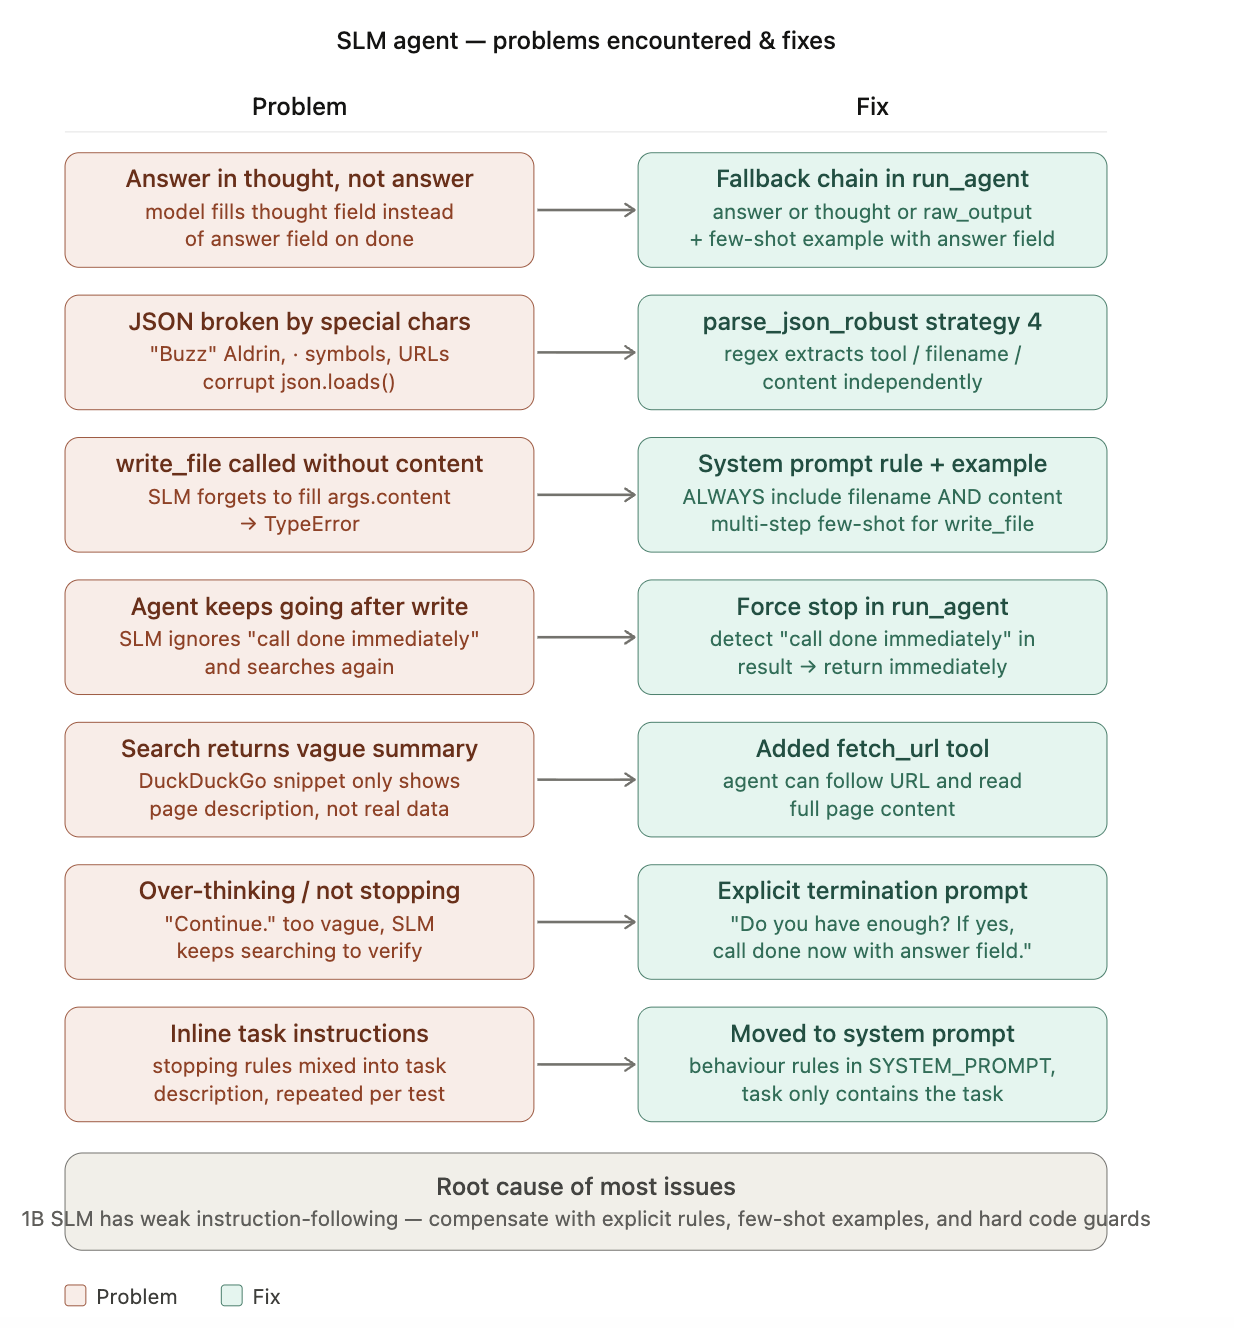

### Saving the agent trace

Unlike the inspector above (which prints to screen and disappears),
`save_history()` writes the full trace to a `.txt` file in `~/agent_workspace/`
so it persists after the notebook is closed. Useful for comparing runs over time.

In [39]:
# ── save_history: write the agent trace to a .txt file ────────────────
def save_history(history: list, task: str, answer: str,
                 filename: str = None) -> str:
    """Save the agent execution trace to ~/agent_workspace/.

    Args:
        history:  The history list returned by run_agent().
        task:     The original task string.
        answer:   The final answer.
        filename: Optional custom filename; auto-generated if omitted.

    Returns:
        Full path to the saved file.
    """
    if not filename:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'trace_{ts}.txt'

    safe = os.path.join(WORKSPACE, os.path.basename(filename))
    lines = [
        '=== AGENT TRACE ===',
        f'Timestamp : {datetime.now().isoformat()}',
        f'Task      : {task}',
        f'Answer    : {answer}',
        f'Steps used: {len(history)}',
        '',
        '=== STEP-BY-STEP ===',
        '',
    ]
    for h in history:
        lines.append(f"Step {h['step']} [{h['tool']}]")
        lines.append(f"  Thought : {h['thought']}")
        if h.get('args'):
            lines.append(f"  Args    : {h['args']}")
        result_str = str(h['result'])
        preview = result_str[:500] + ('...(truncated)' if len(result_str) > 500 else '')
        lines.append(f'  Result  : {preview}')
        lines.append('')

    with open(safe, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    print(f'Trace saved to: {safe}')
    return safe


# Example — save the trace from Test 2 above:
save_history(history, task='Moon landing year', answer=answer)
print('✅ save_history ready')


Trace saved to: /home/jovyan/agent_workspace/trace_20260406_220530.txt
✅ save_history ready


### Comparison: Direct LLM vs Agent

This cell runs the same question two ways side-by-side.
**Expected runtime: 2–5 minutes** (three LLM calls on CPU).

| Method | How it works | Weakness |
|--------|-------------|----------|
| **Direct LLM** | One-shot call, no tools, no loop | Cannot access live or recent data |
| **Agent** | Decides whether to search or answer directly | Small model may over-search or mis-format |

In [40]:
# ── Direct LLM vs Agent comparison ────────────────────────────────────
def ask_direct(question: str) -> str:
    """Ask the model a single question with no agent loop.
    This is a plain one-shot LLM call — the model answers once
    and stops, with no access to any tools.
    """
    resp = llm.create_chat_completion(
        messages=[{'role': 'user', 'content': question}],
        max_tokens=150,
        temperature=0.1
    )
    return resp['choices'][0]['message']['content']

COMPARISON_QUESTIONS = [
    "What is today's crude oil price (WTI) in USD per barrel?",
]

for q in COMPARISON_QUESTIONS:
    print(f'\nQuestion: {q}')
    print('-' * 60)
    direct_ans = ask_direct(q)
    print(f'[Direct LLM]      {direct_ans}')
    agent_ans, hist = run_agent(q, max_steps=5, verbose=False)
    steps = len(hist)
    print(f'[Agent ({steps} steps)]  {agent_ans}')


Question: What is today's crude oil price (WTI) in USD per barrel?
------------------------------------------------------------
[Direct LLM]      I'm not able to provide real-time or the most current information, including the current crude oil price in USD per barrel. The price of crude oil can fluctuate constantly and may vary depending on market conditions, which can change rapidly.

For the most accurate and up-to-date information on the current crude oil price, I recommend checking a reliable financial news source or a reputable market data provider. They can provide you with the latest prices and any other relevant information you may need.
[Step 1] Calling LLM...
[Step 1] LLM responded.
[Step 2] Calling LLM...
[Step 2] LLM responded.
[Agent (2 steps)]  {"thought": "Requires real-time data.", "tool": "search_web", "args": {"query": "WTI vs Brent Crude oil prices difference today"}


### Inspecting the last agent run

`history` always refers to the **most recent `run_agent()` call**.
Re-run any test cell above to update it before inspecting.

In [ ]:
# ── Inspect history — use this to debug when the agent does something unexpected
print('=== AGENT HISTORY ===')
for h in history:
    print(f"\nStep {h['step']} [{h['tool']}]")
    print(f"  Thought: {h['thought']}")
    if h['args']:
        print(f"  Args   : {h['args']}")
    print(f"  Result : {str(h['result'])[:200]}")

> **Notice the `messages` list:** every tool result gets added back into the conversation. This is the agent's **state** — its memory of what has happened. Without it, the model would forget its previous steps and start over each time.

> **Note:** If you see `(no answer)`, the model likely answered in the wrong JSON field.
> This is common with small models. Try a more specific task like:
> `What year was the Moon first landed on?`

## What you just built

### The anatomy of your agent

| Component | Where it lives in the code | What it does |
|---|---|---|
| **Model** | `llm.create_chat_completion()` | Reads the situation and decides the next action |
| **Tools** | `TOOLS` dict + 4 Python functions | Executes real-world actions (search, files, shell) |
| **State** | `messages` list growing with each step | The agent's memory of everything that has happened |
| **Loop** | `for step in range(1, max_steps + 1)` | Keeps the agent running until `done` |
| **Protocol** | JSON `{thought, tool, args}` | How model and loop communicate |

### How this compares to what you built earlier

| Earlier notebook | This agent |
|---|---|
| You send a prompt → model answers → done | You give a task → model keeps working until finished |
| Model can only produce text | Model can search, write files, run code |
| You control every step | Agent decides its own next step |
| One `create_chat_completion()` call | A loop of calls, each building on the last |

### The one-line definition

> **An agent is a model + tools + a loop. Everything else — memory, planning, multi-agent — is built on top of this.**


In [ ]:
# ── Step 6: Agent Concepts Hangman Quiz ──────────────────────────────
display(HTML("""
<button onclick="Jupyter.notebook.execute_cells_below()" 
        style="padding:10px 24px;background:#1d6fa8;color:white;
               border:none;border-radius:8px;font-size:0.9em;
               cursor:pointer;font-family:monospace;font-weight:bold">
  🤖 Launch Quiz
</button>
"""))

QUESTION_POOL = [
    {
        "q": "What are the three core components of every agent?",
        "options": ["Model, Memory, Output", "Model, Tools, Loop", "Prompt, Response, History", "Input, Process, Output"],
        "answer": 1, "explanation": "Every agent needs a brain (Model), hands (Tools), and an engine (Loop) that keeps it running.", "part": "Step 3",
    },
    {
        "q": "What does `tool == 'done'` mean in the agent loop?",
        "options": ["The tool crashed", "The model wants to use a tool called done", "The task is complete — return the answer", "The loop has run out of steps"],
        "answer": 2, "explanation": "done is the exit condition. When the model says done, the loop stops and returns the answer.", "part": "Step 3",
    },
    {
        "q": "Why do we add the tool result back to `messages`?",
        "options": ["To make the response longer", "So the model remembers what happened in previous steps", "To avoid repeating the same tool", "Because the API requires it"],
        "answer": 1, "explanation": "Without adding results to messages, the model starts fresh every step and forgets what it already did.", "part": "Step 3",
    },
    {
        "q": "What is Human-in-the-Loop (HITL)?",
        "options": ["The model asking itself questions", "A human reviewing and approving certain agent actions", "Running the agent in a browser", "A type of memory system"],
        "answer": 1, "explanation": "HITL means a human stays in control of dangerous actions — you are the captain, the AI is the co-pilot.", "part": "Step 2",
    },
    {
        "q": "Why is `write_file` locked to `~/agent_workspace/`?",
        "options": ["To make files easier to find", "To prevent the agent from overwriting system files", "Because the model cannot handle full paths", "To save disk space"],
        "answer": 1, "explanation": "Without this restriction, the agent could accidentally overwrite system files or important data.", "part": "Step 2",
    },
    {
        "q": "What does `parse_json_robust` solve?",
        "options": ["It makes JSON files smaller", "It handles cases where the model adds extra text around the JSON", "It converts Python dicts to JSON", "It speeds up the agent loop"],
        "answer": 1, "explanation": "Small models do not always output clean JSON — they sometimes wrap it in markdown or add commentary.", "part": "Step 3",
    },
    {
        "q": "What is the agent's 'state' in our implementation?",
        "options": ["The HITL toggle value", "The messages list that grows with each step", "The tool result from the last step", "The system prompt"],
        "answer": 1, "explanation": "The messages list is the agent's short-term memory — everything that happened is stored there.", "part": "Step 3",
    },
    {
        "q": "What happens when `max_steps` is reached without a `done`?",
        "options": ["The agent starts over", "The kernel crashes", "The loop returns Max steps reached.", "The last tool result is returned as the answer"],
        "answer": 2, "explanation": "max_steps is a safety limit to prevent infinite loops. The loop exits gracefully with a message.", "part": "Step 3",
    },
    {
        "q": "Why does Llama-3.2-1B sometimes fail on complex tasks?",
        "options": ["It does not have access to the internet", "It is a small model with limited reasoning ability", "The tools are not compatible with it", "The context window is too small"],
        "answer": 1, "explanation": "1 billion parameters is very small. The model struggles to know when to stop or how to combine multiple tools.", "part": "Step 4",
    },
    {
        "q": "What is the difference between a plain LLM call and an agent?",
        "options": ["An agent is faster", "A plain LLM responds once and stops; an agent loops until the task is done", "An agent uses a different model", "There is no difference"],
        "answer": 1, "explanation": "The loop is what makes an agent an agent — it keeps working, using tools, until the task is complete.", "part": "Step 1",
    },
    {
        "q": "What does `TOOLS[tool](**args)` do?",
        "options": ["Looks up the tool name and calls it with the model's arguments", "Prints the tool name", "Adds the tool to the registry", "Validates the tool arguments"],
        "answer": 0, "explanation": "TOOLS is a dict mapping tool names to Python functions. **args unpacks the arguments the model provided.", "part": "Step 3",
    },
    {
        "q": "Which tool requires human approval before running?",
        "options": ["search_web", "write_file", "read_file", "run_shell"],
        "answer": 3, "explanation": "run_shell can execute any command on your machine — it is the most dangerous tool and requires your explicit approval.", "part": "Step 2",
    },
    {
        "q": "Why do we use `os.path.basename()` in `write_file`?",
        "options": ["To get the file extension", "To strip path traversal like ../../ so the agent cannot escape the workspace", "To convert relative paths to absolute paths", "To check if the file exists"],
        "answer": 1, "explanation": "Without basename(), the agent could pass a path like ../../etc/passwd and write outside the workspace.", "part": "Step 2",
    },
    {
        "q": "What does the system prompt tell the model in our agent?",
        "options": ["How fast to respond", "What tools it has and what JSON format to use", "How many steps it can take", "Which files it can access"],
        "answer": 1, "explanation": "The system prompt is the instruction manual — it tells the model about available tools and the exact JSON format to respond in.", "part": "Step 3",
    },
    {
        "q": "What is the purpose of few-shot examples in the system prompt?",
        "options": ["To make the prompt longer", "To show the model what a correct JSON response looks like", "To list all available tools", "To set the temperature"],
        "answer": 1, "explanation": "Few-shot examples dramatically improve JSON compliance — especially for small models that need to see the format in action.", "part": "Step 3",
    },
    {
        "q": "In our agent, what format does the model use to communicate its decisions?",
        "options": ["Plain English sentences", "Python code", "JSON with thought, tool, and args fields", "XML"],
        "answer": 2, "explanation": "The model responds with JSON like {thought, tool, args} so our loop can parse exactly which tool to call and with what arguments.", "part": "Step 3",
    },
    {
        "q": "What happens if the model calls a tool that is not in TOOLS?",
        "options": ["The loop crashes", "The agent skips that step", "An error string is returned and added to messages", "The model tries again automatically"],
        "answer": 2, "explanation": "We catch unknown tools and return a clear error message — the model then sees this in the next step and can recover.", "part": "Step 3",
    },
    {
        "q": "Why do we snapshot widget values before starting the thread in the UI?",
        "options": ["To speed up the thread", "To prevent the user from changing values while the agent is running", "Because threads cannot access widgets", "To save memory"],
        "answer": 1, "explanation": "If the user changes the input while the thread is running, the agent would use the new values mid-task. Snapshotting prevents this.", "part": "Step 4",
    },
]

NUM_QUESTIONS = 8
MAX_WRONG     = 6
pool_json     = json.dumps(QUESTION_POOL)

html = f"""
<style>
  .hm-wrap {{
    font-family: 'IBM Plex Mono', 'Fira Code', monospace;
    background: #f8fafc;
    border-radius: 14px;
    padding: 20px;
    max-width: 860px;
  }}
  .hm-header {{
    background: linear-gradient(135deg, #eff6ff, #dbeafe);
    border: 1px solid #bfdbfe;
    border-radius: 12px;
    padding: 16px 20px;
    margin-bottom: 16px;
    display: flex;
    justify-content: space-between;
    align-items: center;
  }}
  .hm-title {{ color: #1a1a2e; font-weight: 700; font-size: 1.05em; }}
  .hm-sub   {{ color: #475569; font-size: 0.72em; margin-top: 4px; }}
  .hm-body  {{ display: flex; gap: 20px; align-items: flex-start; margin-bottom: 16px; }}
  .hm-scaffold {{
    flex-shrink: 0; background: #ffffff; border: 1px solid #d1d5db;
    border-radius: 12px; padding: 12px;
    display: flex; flex-direction: column; align-items: center; gap: 8px; width: 160px;
  }}
  .hm-lives {{ font-size: 0.72em; color: #475569; text-align: center; }}
  .hm-lives span {{ color: #f87171; font-weight: 700; }}
  .hm-qpanel {{ flex: 1; }}
  .hm-progress {{
    font-size: 0.72em; color: #475569; margin-bottom: 10px;
    display: flex; justify-content: space-between;
  }}
  .hm-progress .correct-count {{ color: #059669; font-weight: 700; }}
  .hm-progress .wrong-count   {{ color: #f87171;  font-weight: 700; }}
  .q-block {{ background: #ffffff; border: 1px solid #d1d5db; border-radius: 12px; padding: 16px 18px; }}
  .q-meta  {{ display: flex; align-items: center; gap: 8px; margin-bottom: 10px; }}
  .q-part  {{
    background: #bfdbfe; color: #0369a1; font-size: 0.62em; font-weight: 700;
    padding: 2px 9px; border-radius: 20px; text-transform: uppercase; letter-spacing: 0.05em;
  }}
  .q-num  {{ color: #475569; font-size: 0.68em; }}
  .q-text {{ color: #475569; font-size: 0.88em; font-weight: 600; line-height: 1.6; margin-bottom: 12px; }}
  .opt {{
    background: #f3f4f6; border: 1px solid #d1d5db; border-radius: 8px;
    padding: 11px 14px; margin-bottom: 7px; cursor: pointer;
    display: flex; align-items: flex-start; gap: 10px;
    transition: border-color 0.15s, background 0.15s;
  }}
  .opt:hover {{ border-color: #0369a1; background: #e0f2fe; }}
  .opt-letter {{
    background: #e5e7eb; color: #64748b; font-size: 0.70em; font-weight: 700;
    width: 20px; height: 20px; border-radius: 50%;
    display: flex; align-items: center; justify-content: center; flex-shrink: 0; margin-top: 1px;
  }}
  .opt-text {{ color: #64748b; font-size: 0.82em; line-height: 1.5; }}
  .opt.correct {{ background: #dcfce7; border-color: #059669; cursor: default; }}
  .opt.correct .opt-letter {{ background: #059669; color: #dcfce7; }}
  .opt.correct .opt-text   {{ color: #166534; }}
  .opt.wrong   {{ background: #fee2e2; border-color: #f87171; cursor: default; }}
  .opt.wrong .opt-letter   {{ background: #f87171; color: #fee2e2; }}
  .opt.wrong .opt-text     {{ color: #e53935; }}
  .opt.locked  {{ cursor: default; }}
  .opt.locked:hover        {{ border-color: #d1d5db; background: #f3f4f6; }}
  .opt.locked.correct:hover {{ border-color: #059669; background: #dcfce7; }}
  .opt.dim {{ opacity: 0.35; cursor: default; pointer-events: none; }}
  .feedback {{
    margin-top: 8px; padding: 10px 14px; border-radius: 0 8px 8px 0;
    font-size: 0.78em; line-height: 1.6; color: #475569; display: none;
  }}
  .feedback.show       {{ display: block; }}
  .feedback.correct-fb {{ background: #05966910; border-left: 3px solid #059669; }}
  .feedback.wrong-fb   {{ background: #f8717110; border-left: 3px solid #f87171; }}
  .next-btn {{
    margin-top: 12px; padding: 8px 20px; border-radius: 8px;
    background: #bfdbfe; border: 1px solid #0369a1; color: #0369a1;
    font-family: inherit; font-size: 0.82em; font-weight: 700;
    cursor: pointer; display: none; transition: background 0.15s;
  }}
  .next-btn:hover  {{ background: #e0f2fe; }}
  .next-btn.visible {{ display: inline-block; }}
  .final-screen {{ background: #ffffff; border-radius: 12px; padding: 28px 24px; text-align: center; display: none; }}
  .final-screen.show {{ display: block; }}
  .final-big {{ font-size: 3.0em; font-weight: 700; line-height: 1; margin-bottom: 8px; }}
  .final-msg {{ font-size: 0.88em; margin-bottom: 16px; }}
  .retry-btn {{
    display: inline-block; padding: 10px 24px; border-radius: 8px;
    font-family: inherit; font-size: 0.85em; font-weight: 700;
    cursor: pointer; border: 1px solid; transition: opacity 0.15s;
  }}
  .retry-btn:hover {{ opacity: 0.75; }}
  .hm-stroke {{ opacity: 0; transition: opacity 0.3s; }}
  .hm-stroke.drawn {{ opacity: 1; }}
</style>

<div class="hm-wrap">

  <div class="hm-header">
    <div>
      <div style="font-size:0.58em;color:#0284c7;text-transform:uppercase;letter-spacing:0.15em;margin-bottom:3px">Step 6 — Final Quiz</div>
      <div class="hm-title">🤖 Robot Rescue Quiz</div>
      <div class="hm-sub">Wrong answer = one part falls off. 6 wrong = robot destroyed.</div>
    </div>
    <div style="text-align:right;color:#475569;font-size:0.70em">
      <div>{NUM_QUESTIONS} questions</div>
      <div style="color:#0284c7;font-weight:700">{MAX_WRONG} lives</div>
    </div>
  </div>

  <div class="hm-body">

    <div class="hm-scaffold">
      <svg width="120" height="150" viewBox="0 0 120 150">

        <!-- Base platform -->
        <rect x="20" y="138" width="80" height="8" rx="3" fill="#bfdbfe"/>

        <!-- Legs -->
        <rect class="hm-stroke" id="hm-s6" x="38" y="108" width="14" height="30" rx="4" fill="#93c5fd" stroke="#3b82f6" stroke-width="1"/>
        <rect class="hm-stroke" id="hm-s5" x="68" y="108" width="14" height="30" rx="4" fill="#93c5fd" stroke="#3b82f6" stroke-width="1"/>

        <!-- Arms -->
        <rect class="hm-stroke" id="hm-s4" x="8"  y="62" width="24" height="10" rx="4" fill="#fca5a5" stroke="#f87171" stroke-width="1"/>
        <rect class="hm-stroke" id="hm-s3" x="88" y="62" width="24" height="10" rx="4" fill="#fca5a5" stroke="#f87171" stroke-width="1"/>

        <!-- Body -->
        <rect class="hm-stroke" id="hm-s2" x="32" y="55" width="56" height="55" rx="8" fill="#bfdbfe" stroke="#3b82f6" stroke-width="1.5"/>
        <!-- Body details (only visible when body is drawn) -->
        <rect class="hm-stroke" id="hm-s2b" x="42" y="68" width="14" height="10" rx="2" fill="#3b82f6" opacity="0.5"/>
        <rect class="hm-stroke" id="hm-s2c" x="64" y="68" width="14" height="10" rx="2" fill="#3b82f6" opacity="0.5"/>
        <rect class="hm-stroke" id="hm-s2d" x="42" y="85" width="36" height="6"  rx="3" fill="#93c5fd"/>

        <!-- Neck -->
        <rect class="hm-stroke" id="hm-s1b" x="50" y="45" width="20" height="12" rx="3" fill="#93c5fd" stroke="#3b82f6" stroke-width="1"/>

        <!-- Head -->
        <rect class="hm-stroke" id="hm-s1" x="30" y="12" width="60" height="36" rx="10" fill="#bfdbfe" stroke="#3b82f6" stroke-width="1.5"/>
        <!-- Eyes -->
        <circle class="hm-stroke" id="hm-s1c" cx="50" cy="28" r="6" fill="#ffffff" stroke="#3b82f6" stroke-width="1"/>
        <circle class="hm-stroke" id="hm-s1d" cx="70" cy="28" r="6" fill="#ffffff" stroke="#3b82f6" stroke-width="1"/>
        <circle class="hm-stroke" id="hm-s1e" cx="50" cy="28" r="3" fill="#3b82f6"/>
        <circle class="hm-stroke" id="hm-s1f" cx="70" cy="28" r="3" fill="#3b82f6"/>
        <!-- Antenna -->
        <line  class="hm-stroke" id="hm-s1g" x1="60" y1="12" x2="60" y2="4"  stroke="#3b82f6" stroke-width="2" stroke-linecap="round"/>
        <circle class="hm-stroke" id="hm-s1h" cx="60" cy="3" r="3" fill="#f87171"/>

      </svg>
      <div class="hm-lives">Lives left: <span id="lives-left">{MAX_WRONG}</span></div>
      <div id="wrong-pills" style="display:flex;flex-wrap:wrap;gap:3px;justify-content:center;margin-top:4px"></div>
    </div>

    <div class="hm-qpanel">
      <div class="hm-progress">
        <span>Question <span id="q-current">1</span> / {NUM_QUESTIONS}</span>
        <span>
          <span class="correct-count" id="correct-count">0</span> correct &nbsp;
          <span class="wrong-count"   id="wrong-count">0</span> wrong
        </span>
      </div>
      <div id="q-container"></div>
    </div>

  </div>

  <div class="final-screen" id="final-screen"></div>

</div>

<script>
(function() {{

  var POOL      = {pool_json};
  var N         = {NUM_QUESTIONS};
  var MAX_WRONG = {MAX_WRONG};

  var wrongCount   = 0;
  var correctCount = 0;
  var qIndex       = 0;
  var questions    = [];
  var gameOver     = false;

  var qContainer = document.getElementById('q-container');
  var livesLeft  = document.getElementById('lives-left');
  var wrongPills = document.getElementById('wrong-pills');
  var qCurrent   = document.getElementById('q-current');
  var correctEl  = document.getElementById('correct-count');
  var wrongEl    = document.getElementById('wrong-count');
  var finalScreen= document.getElementById('final-screen');

  // Robot parts disappear in this order: antenna/eyes(head details) → head → neck → left arm → right arm → left leg → right leg
  var STROKE_GROUPS = [
    ['hm-s1g','hm-s1h','hm-s1c','hm-s1d','hm-s1e','hm-s1f'],  // wrong 1: head details
    ['hm-s1','hm-s1b'],                                          // wrong 2: head + neck
    ['hm-s2','hm-s2b','hm-s2c','hm-s2d'],                       // wrong 3: body
    ['hm-s3'],                                                    // wrong 4: right arm
    ['hm-s4'],                                                    // wrong 5: left arm
    ['hm-s5','hm-s6'],                                           // wrong 6: both legs
  ];

  function shuffle(arr) {{
    var a = arr.slice();
    for (var i = a.length-1; i > 0; i--) {{
      var j = Math.floor(Math.random()*(i+1));
      var t = a[i]; a[i]=a[j]; a[j]=t;
    }}
    return a;
  }}

  function showAll() {{
    STROKE_GROUPS.forEach(function(group) {{
      group.forEach(function(id) {{
        var el = document.getElementById(id);
        if (el) el.classList.add('drawn');
      }});
    }});
  }}

  function hideGroup(n) {{
    var group = STROKE_GROUPS[n-1];
    if (!group) return;
    group.forEach(function(id) {{
      var el = document.getElementById(id);
      if (el) el.classList.remove('drawn');
    }});
  }}

  function renderQuestion(qi) {{
    var q = questions[qi];
    qCurrent.textContent = qi + 1;
    var opts = '';
    q.options.forEach(function(opt, oi) {{
      opts +=
        '<div class="opt" id="opt-'+oi+'" onclick="hmAnswer('+oi+')">' +
          '<div class="opt-letter">'+String.fromCharCode(65+oi)+'</div>' +
          '<div class="opt-text">'+opt+'</div>' +
        '</div>';
    }});
    qContainer.innerHTML =
      '<div class="q-block">' +
        '<div class="q-meta">' +
          '<span class="q-part">'+q.part+'</span>' +
          '<span class="q-num">Q'+(qi+1)+'</span>' +
        '</div>' +
        '<div class="q-text">'+q.q+'</div>' +
        opts +
        '<div class="feedback" id="fb"></div>' +
        '<button class="next-btn" id="next-btn" onclick="hmNext()">Next question →</button>' +
      '</div>';
  }}

  window.hmAnswer = function(oi) {{
    if (gameOver) return;
    var q       = questions[qIndex];
    var correct = q.answer;
    var isRight = (oi === correct);
    var fb      = document.getElementById('fb');
    var nextBtn = document.getElementById('next-btn');

    for (var j = 0; j < q.options.length; j++) {{
      var el = document.getElementById('opt-'+j);
      if (!el) continue;
      el.classList.add('locked');
      el.removeAttribute('onclick');
      if (j === correct)  el.classList.add('correct');
      else if (j === oi)  el.classList.add('wrong');
      else                el.classList.add('dim');
    }}

    if (isRight) {{
      correctCount++;
      correctEl.textContent = correctCount;
      fb.className = 'feedback show correct-fb';
      fb.innerHTML = '✅ <strong style="color:#059669">Correct!</strong> ' + q.explanation;
    }} else {{
      wrongCount++;
      wrongEl.textContent = wrongCount;
      hideGroup(wrongCount);
      livesLeft.textContent = MAX_WRONG - wrongCount;
      var pill = document.createElement('div');
      pill.style.cssText = 'background:#f8717120;border:1px solid #f87171;border-radius:4px;padding:1px 6px;font-size:0.65em;color:#f87171';
      pill.textContent = '✗';
      wrongPills.appendChild(pill);
      fb.className = 'feedback show wrong-fb';
      fb.innerHTML = '❌ <strong style="color:#f87171">Wrong.</strong> ' + q.explanation;
      if (wrongCount >= MAX_WRONG) {{
        gameOver = true;
        setTimeout(function() {{ showFinal(false); }}, 1200);
        return;
      }}
    }}

    nextBtn.textContent = (qIndex >= N-1) ? '🏁 See results' : 'Next question →';
    nextBtn.classList.add('visible');
  }};

  window.hmNext = function() {{
    qIndex++;
    if (qIndex >= N) showFinal(true);
    else renderQuestion(qIndex);
  }};

  function showFinal(completed) {{
    document.querySelector('.hm-body').style.display = 'none';
    finalScreen.classList.add('show');
    var pct = Math.round(correctCount/N*100);
    var color, emoji, msg;
    if (!completed) {{
      color='#f87171'; emoji='💀'; msg='Robot destroyed! The agent is no more...';
    }} else if (correctCount === N) {{
      color='#059669'; emoji='🤖✨'; msg='Perfect! The robot is fully operational!';
    }} else if (correctCount >= Math.ceil(N*0.7)) {{
      color='#f9a825'; emoji='🔧'; msg='Robot needs some repairs — but survived!';
    }} else {{
      color='#f87171'; emoji='⚠️'; msg='Critical damage! Re-read Steps 2 and 3.';
    }}
    finalScreen.innerHTML =
      '<div class="final-big" style="color:'+color+'">'+emoji+'</div>' +
      '<div style="color:'+color+';font-weight:700;font-size:1.1em;margin-bottom:6px">'+msg+'</div>' +
      '<div class="final-msg" style="color:#374151">' +
        'Score: <strong style="color:'+color+'">'+correctCount+'/'+N+' ('+pct+'%)</strong>' +
        ' &nbsp;·&nbsp; Wrong: <strong style="color:#f87171">'+wrongCount+'</strong>' +
      '</div>' +
      '<button class="retry-btn" style="background:'+color+'18;border-color:'+color+';color:'+color+'" ' +
              'onclick="hmRestart()">🔄 Play Again</button>';
  }}

  window.hmRestart = function() {{
    wrongCount=correctCount=qIndex=0; gameOver=false;
    livesLeft.textContent=MAX_WRONG;
    wrongPills.innerHTML='';
    correctEl.textContent='0';
    wrongEl.textContent='0';
    document.querySelector('.hm-body').style.display='flex';
    finalScreen.classList.remove('show');
    showAll();
    questions=shuffle(POOL).slice(0,N);
    renderQuestion(0);
  }};

  questions = shuffle(POOL).slice(0,N);
  showAll();
  renderQuestion(0);

}})();
</script>
"""

display(HTML(html))